In [5]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


Control shape: (143462, 6)
Test shape:    (177847, 6)

--- Processing Control group ---
Error rate per step:
  process_step  error_rate_control
0      confirm            0.000000
1        start            0.101117
2       step_1            0.077659
3       step_2            0.091439
4       step_3            0.005703

--- Processing Test group ---
Error rate per step:
  process_step  error_rate_test
0      confirm         0.000000
1        start         0.186174
2       step_1         0.088114
3       step_2         0.073833
4       step_3         0.001120

--- Step-by-step error rate comparison ---
  process_step  error_rate_control  error_rate_test
0        start            0.101117         0.186174
1       step_1            0.077659         0.088114
2       step_2            0.091439         0.073833
3       step_3            0.005703         0.001120
4      confirm            0.000000         0.000000

Control error rate: 0.2033
Test error rate:    0.2684

Z-statistic: -20.0841
P-v

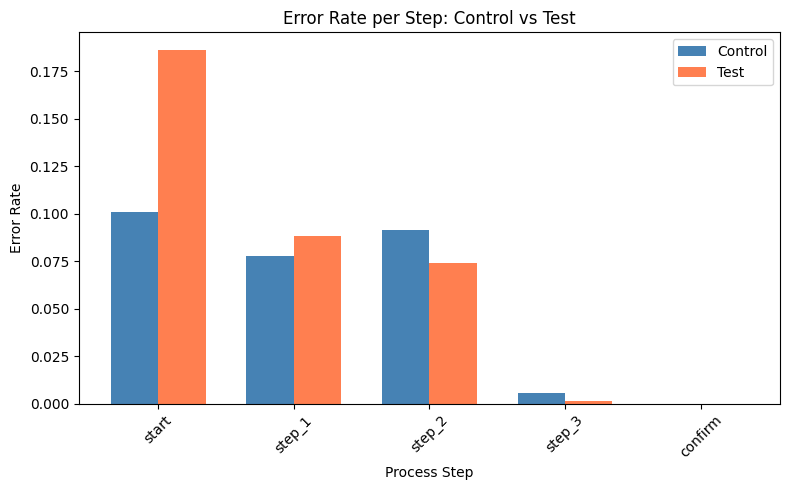

Done! Files saved next to your notebook.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# ── Step 1: Load clean data ──────────────────────────────────────────────────
web_data = pd.read_csv('../data/clean/clean_web_data.csv')
experiment_clients = pd.read_csv('../data/clean/df_final_experiment_clients_clean.csv')

# Merge to bring in the variation column
web_data = web_data.merge(experiment_clients, on='client_id', how='inner')

# Split into control and test
df_control = web_data[web_data['variation'] == 'Control'].copy()
df_test    = web_data[web_data['variation'] == 'Test'].copy()

print("Control shape:", df_control.shape)
print("Test shape:   ", df_test.shape)

# ── Step 2: Define funnel order ──────────────────────────────────────────────
step_order = {
    'start':   0,
    'step_1':  1,
    'step_2':  2,
    'step_3':  3,
    'confirm': 4
}

# ── Step 3: Error rate per step ──────────────────────────────────────────────
def error_rate_per_step(df, label):
    df = df.copy()
    print(f"\n--- Processing {label} group ---")

    df['step_num'] = df['process_step'].map(step_order)
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values(['client_id', 'visit_id', 'date_time'])
    df['prev_step'] = df.groupby(['client_id', 'visit_id'])['step_num'].shift(1)
    df['error'] = df['step_num'] < df['prev_step']

    step_errors = df.groupby('process_step')['error'].mean().reset_index()
    step_errors.columns = ['process_step', f'error_rate_{label.lower()}']
    print(f"Error rate per step:\n{step_errors}")

    return df, step_errors

df_control_flagged, control_step_errors = error_rate_per_step(df_control, "Control")
df_test_flagged,    test_step_errors    = error_rate_per_step(df_test,    "Test")

# ── Step 4: Merge & order for comparison ────────────────────────────────────
order = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
comparison = control_step_errors.merge(test_step_errors, on='process_step', how='outer')
comparison = comparison.set_index('process_step').loc[order].reset_index()

print("\n--- Step-by-step error rate comparison ---")
print(comparison)

# ── Step 5: Overall error rates ──────────────────────────────────────────────
control_n      = df_control_flagged['visit_id'].nunique()
test_n         = df_test_flagged['visit_id'].nunique()
control_errors = df_control_flagged.groupby('visit_id')['error'].any().sum()
test_errors    = df_test_flagged.groupby('visit_id')['error'].any().sum()
control_rate   = control_errors / control_n
test_rate      = test_errors    / test_n

print(f"\nControl error rate: {control_rate:.4f}")
print(f"Test error rate:    {test_rate:.4f}")

# ── Step 6: Hypothesis test ──────────────────────────────────────────────────
z_stat, p_value = proportions_ztest([control_errors, test_errors], [control_n, test_n])

print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("Reject H0: The difference in error rates is statistically significant.")
else:
    print("Fail to reject H0: No significant difference in error rates detected.")

# ── Step 7: Interpretation ───────────────────────────────────────────────────
if test_rate < control_rate:
    print("\nInterpretation: The Test group has a LOWER error rate — the new UI reduces user errors.")
else:
    print("\nInterpretation: The Test group has a HIGHER error rate — the new UI does not reduce errors.")

# ── Step 8: Plot ─────────────────────────────────────────────────────────────
x     = np.arange(len(comparison['process_step']))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, comparison['error_rate_control'], width, label='Control', color='steelblue')
plt.bar(x + width/2, comparison['error_rate_test'],    width, label='Test',    color='coral')

plt.xticks(x, comparison['process_step'], rotation=45)
plt.title('Error Rate per Step: Control vs Test')
plt.ylabel('Error Rate')
plt.xlabel('Process Step')
plt.legend()
plt.tight_layout()
plt.show()

# ── Step 9: Export ───────────────────────────────────────────────────────────
df_control_flagged.to_csv('df_control_updated.csv', index=False)
df_test_flagged.to_csv('df_test_updated.csv', index=False)

print("Done! Files saved next to your notebook.")

In [8]:
print(experiment_clients.columns.tolist())

['client_id', 'variation']


In [ ]:
import os

for root, dirs, files in os.walk('.'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

In [10]:
control_step_errors.to_csv('control_error_rates.csv', index=False)
test_step_errors.to_csv('test_error_rates.csv', index=False)

print("Done!")

Done!


In [11]:
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# ── Hypothesis Test: Error Rate ──────────────────────────────────────────────
# H0: error rate is the same in both groups (new UI made no difference)
# H1: error rate is different between groups (new UI made a difference)

print("=" * 55)
print("HYPOTHESIS TEST: ERROR RATE (Control vs Test)")
print("=" * 55)
print(f"Control: {control_errors} errors out of {control_n} sessions ({control_rate:.2%})")
print(f"Test:    {test_errors} errors out of {test_n} sessions ({test_rate:.2%})")

# Z-test
z_stat, p_value = proportions_ztest([control_errors, test_errors], [control_n, test_n])
print(f"\nZ-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ Reject H0 (p < {alpha}): The difference in error rates is statistically significant.")
else:
    print(f"\n❌ Fail to reject H0 (p >= {alpha}): No significant difference detected.")

# ── Confidence Intervals ─────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("95% CONFIDENCE INTERVALS")
print("=" * 55)

ci_control = proportion_confint(control_errors, control_n, alpha=0.05, method='normal')
ci_test    = proportion_confint(test_errors,    test_n,    alpha=0.05, method='normal')

print(f"Control: ({ci_control[0]:.2%}, {ci_control[1]:.2%})")
print(f"Test:    ({ci_test[0]:.2%}, {ci_test[1]:.2%})")

# ── Practical Significance ───────────────────────────────────────────────────
print("\n" + "=" * 55)
print("PRACTICAL SIGNIFICANCE")
print("=" * 55)

diff = test_rate - control_rate
print(f"Difference in error rate (Test - Control): {diff:.2%}")

if diff > 0:
    print("The Test group has a HIGHER error rate — the new UI introduces more user errors.")
else:
    print("The Test group has a LOWER error rate — the new UI reduces user errors.")

# ── Per-step conclusions ──────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("PER-STEP ANALYSIS")
print("=" * 55)
for _, row in comparison.iterrows():
    step = row['process_step']
    ctrl = row['error_rate_control']
    test = row['error_rate_test']
    diff_step = test - ctrl
    direction = "higher ⚠️" if diff_step > 0 else "lower ✅"
    print(f"{step}: Control={ctrl:.2%}, Test={test:.2%} → Test is {abs(diff_step):.2%} {direction}")

HYPOTHESIS TEST: ERROR RATE (Control vs Test)
Control: 6543 errors out of 32189 sessions (20.33%)
Test:    9968 errors out of 37136 sessions (26.84%)

Z-statistic: -20.0841
P-value:     0.0000

✅ Reject H0 (p < 0.05): The difference in error rates is statistically significant.

95% CONFIDENCE INTERVALS
Control: (19.89%, 20.77%)
Test:    (26.39%, 27.29%)

PRACTICAL SIGNIFICANCE
Difference in error rate (Test - Control): 6.52%
The Test group has a HIGHER error rate — the new UI introduces more user errors.

PER-STEP ANALYSIS
start: Control=10.11%, Test=18.62% → Test is 8.51% higher ⚠️
step_1: Control=7.77%, Test=8.81% → Test is 1.05% higher ⚠️
step_2: Control=9.14%, Test=7.38% → Test is 1.76% lower ✅
step_3: Control=0.57%, Test=0.11% → Test is 0.46% lower ✅
confirm: Control=0.00%, Test=0.00% → Test is 0.00% lower ✅


In [12]:
comparison.to_csv('error_rates_combined.csv', index=False)
print("Done!")

Done!


In [13]:
# Convert to Tableau-friendly format (long format)
error_rate_step_tableau = comparison.melt(
    id_vars='process_step',
    value_vars=['error_rate_control', 'error_rate_test'],
    var_name='variation',
    value_name='error_rate'
)

# Clean names
error_rate_step_tableau['variation'] = error_rate_step_tableau['variation'].replace({
    'error_rate_control': 'Control',
    'error_rate_test': 'Test'
})

# Save file
error_rate_step_tableau.to_csv('../data/clean/error_rate_by_step_tableau.csv', index=False)

print("CSV exported successfully!")

CSV exported successfully!
